**⚠️ NUMPY COMPATIBILITY FIX:**

The "Numpy is not available" error happens when NumPy 2.x is installed with PyTorch 2.2.x.

**Solution:** Run this in terminal:
```bash
cd /Users/anton/Documents/GitHub/Final_Year_Project
python3 -m pip install 'numpy<2.0' 'opencv-python<4.13'
```

Then **restart the kernel** (Kernel → Restart Kernel) and run all cells from the top.

## 1. Environment Setup

First, we'll install all required packages and verify that we have access to a GPU for training.

In [1]:
# Install required packages
import subprocess
import sys

print(f"Using Python: {sys.executable}")

# Force-reinstall key packages to ensure a consistent environment
core_packages = [
    "numpy<2.0",
    "torch==2.2.2",
    "torchvision==0.17.2",
    "opencv-python<4.13",
]

print("Installing core packages (forced reinstall)...")
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "--force-reinstall", "--no-cache-dir",
    *core_packages
])

packages = [
    "ultralytics>=8.0.0",
    "scikit-learn>=1.3.0",
    "matplotlib>=3.7.0",
    "seaborn>=0.12.0",
    "pyyaml>=6.0",
    "tqdm>=4.65.0",
]

print("\nInstalling remaining packages...")
for package in packages:
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])
    except subprocess.CalledProcessError:
        print(f"Warning: Failed to install {package}")

print("\n✓ All packages installed!")
print("⚠️  IMPORTANT: Please restart the kernel (Kernel → Restart) before proceeding!")

Using Python: /usr/local/bin/python3
Installing core packages (forced reinstall)...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.6 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.7/150.8 MB 19.2 MB/s eta 0:00:08Collecting MarkupSafe>=2.0 (from jinja2->torch==2.2.2)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.8/150.8 MB 101.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.8/150.8 MB 101.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 108.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 108.2 MB

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip



Installing remaining packages...



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip3 install --upgr


✓ All packages installed!
⚠️  IMPORTANT: Please restart the kernel (Kernel → Restart) before proceeding!



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


In [2]:
# Import libraries
import os
import json
import time
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from ultralytics import YOLO
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from tqdm.auto import tqdm

# Sanity check: ensure torch can access numpy
try:
    _ = torch.from_numpy(np.array([1, 2, 3], dtype=np.float32))
    numpy_ok = True
except Exception as exc:
    numpy_ok = False
    print("⚠️ NumPy-PyTorch interop failed:", exc)

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ All imports successful!")
print(f"  NumPy version: {np.__version__}")
print(f"  PyTorch version: {torch.__version__}")
print(f"  NumPy-PyTorch interop: {'OK' if numpy_ok else 'FAILED'}")

if not numpy_ok:
    raise RuntimeError(
        "NumPy-PyTorch interop failed. Restart the kernel and rerun the install cell."
    )

✓ All imports successful!
  NumPy version: 1.26.4
  PyTorch version: 2.2.2
  NumPy-PyTorch interop: OK


In [3]:
# Check GPU availability
print("=" * 70)
print("HARDWARE CONFIGURATION")
print("=" * 70)

# Check CUDA
if torch.cuda.is_available():
    print(f"✓ GPU Available: {torch.cuda.get_device_name(0)}")
    print(f"  CUDA Version: {torch.version.cuda}")
    print(f"  GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    device = "0"  # Use first GPU
else:
    print("⚠ No GPU detected - using CPU (training will be slower)")
    device = "cpu"

print(f"  PyTorch Version: {torch.__version__}")
print(f"  Device: {device}")
print("=" * 70)

HARDWARE CONFIGURATION
⚠ No GPU detected - using CPU (training will be slower)
  PyTorch Version: 2.2.2
  Device: cpu


## 2. Data Preparation

### 2.1 Configure Data Path

The dataset is available in the current project directory.

In [4]:
# Configuration
PROJECT_ROOT = Path.cwd()  # Current notebook directory
DATA_PATH = PROJECT_ROOT  # Data is in current directory

print(f"Project Root: {PROJECT_ROOT}")
print(f"Data Path: {DATA_PATH}")

Project Root: /Users/anton/Documents/GitHub/Final_Year_Project
Data Path: /Users/anton/Documents/GitHub/Final_Year_Project


In [5]:
# Check if dataset exists in current directory
import subprocess

# Check for the dataset directory
dataset_dir = DATA_PATH / "concrete-crack-images-for-classification"

if dataset_dir.exists():
    print(f"✓ Dataset directory found: {dataset_dir}")
    
    # Check for Positive/Negative folders
    positive_dir = dataset_dir / "Positive"
    negative_dir = dataset_dir / "Negative"
    
    if positive_dir.exists() and negative_dir.exists():
        pos_count = len(list(positive_dir.glob("*.jpg")) + list(positive_dir.glob("*.png")))
        neg_count = len(list(negative_dir.glob("*.jpg")) + list(negative_dir.glob("*.png")))
        print(f"  Positive (cracked): {pos_count} images")
        print(f"  Negative (not cracked): {neg_count} images")
        print(f"  Total: {pos_count + neg_count} images")
    else:
        print("⚠ Positive/Negative folders not found in dataset directory")
else:
    print(f"✗ Dataset directory not found: {dataset_dir}")
    print("\nPlease ensure the dataset is in the current directory.")
    print("Expected structure:")
    print("  concrete-crack-images-for-classification/")
    print("    Positive/")
    print("    Negative/")

✓ Dataset directory found: /Users/anton/Documents/GitHub/Final_Year_Project/concrete-crack-images-for-classification
  Positive (cracked): 20000 images
  Negative (not cracked): 20000 images
  Total: 40000 images
  Positive (cracked): 20000 images
  Negative (not cracked): 20000 images
  Total: 40000 images


### 2.2 Setup Raw Classification Data Structure

We'll create a standard structure with `cracked` and `not_cracked` folders.

In [6]:
# Setup raw_classification structure using symlinks to existing data
dataset_dir = DATA_PATH / "concrete-crack-images-for-classification"
raw_classification = DATA_PATH / "raw_classification"

dataset_exists = False

# Create raw_classification directory structure if it doesn't exist
if not raw_classification.exists():
    print("Creating raw_classification structure...")
    raw_classification.mkdir(exist_ok=True)
    
    # Create symlinks to Positive (cracked) and Negative (not_cracked)
    positive_dir = dataset_dir / "Positive"
    negative_dir = dataset_dir / "Negative"
    
    cracked_link = raw_classification / "cracked"
    not_cracked_link = raw_classification / "not_cracked"
    
    if positive_dir.exists() and negative_dir.exists():
        if cracked_link.exists() or cracked_link.is_symlink():
            cracked_link.unlink()
        cracked_link.symlink_to(positive_dir.resolve())
        
        if not_cracked_link.exists() or not_cracked_link.is_symlink():
            not_cracked_link.unlink()
        not_cracked_link.symlink_to(negative_dir.resolve())
        
        print("✓ Created symlinks:")
        print(f"  cracked -> {positive_dir}")
        print(f"  not_cracked -> {negative_dir}")
    else:
        print("✗ Source directories not found")
        print(f"  Looking for: {positive_dir}")
        print(f"  Looking for: {negative_dir}")

# Verify and count images
if raw_classification.exists():
    cracked_check = raw_classification / "cracked"
    not_cracked_check = raw_classification / "not_cracked"
    
    if cracked_check.exists() and not_cracked_check.exists():
        # Count images
        extensions = {".jpg", ".jpeg", ".png", ".bmp"}
        cracked_count = len([p for p in cracked_check.iterdir() if p.suffix.lower() in extensions])
        not_cracked_count = len([p for p in not_cracked_check.iterdir() if p.suffix.lower() in extensions])
        
        if cracked_count > 0 and not_cracked_count > 0:
            dataset_exists = True
            print(f"\n✓ Dataset ready!")
            print(f"  Cracked: {cracked_count} images")
            print(f"  Not cracked: {not_cracked_count} images")
            print(f"  Total: {cracked_count + not_cracked_count} images")
        else:
            print("\n⚠ Dataset directories exist but no images found")
    else:
        print("\n⚠ cracked/not_cracked directories not found in raw_classification")

if not dataset_exists:
    print("\n✗ Dataset not properly configured")
    print("Please ensure the dataset exists in:")
    print(f"  {dataset_dir}")


✓ Dataset ready!
  Cracked: 20000 images
  Not cracked: 20000 images
  Total: 40000 images


In [7]:
# Verify data structure is ready
print("Verifying data structure...")
print()

# Check for classification data
raw_classification = DATA_PATH / "raw_classification"
if raw_classification.exists():
    print("✓ Classification data structure:")
    for class_dir in sorted(raw_classification.iterdir()):
        if class_dir.is_dir():
            num_images = len(list(class_dir.glob("*.jpg")) + list(class_dir.glob("*.png")))
            print(f"  - {class_dir.name}: {num_images} images")
else:
    print("✗ raw_classification directory not found")

print()

# Check for segmentation data (optional)
raw_segmentation = DATA_PATH / "raw_segmentation"
if raw_segmentation.exists():
    images_dir = raw_segmentation / "images"
    masks_dir = raw_segmentation / "masks"
    if images_dir.exists() and masks_dir.exists():
        num_images = len(list(images_dir.glob("*.jpg")) + list(images_dir.glob("*.png")))
        num_masks = len(list(masks_dir.glob("*.jpg")) + list(masks_dir.glob("*.png")))
        print(f"✓ Segmentation data found:")
        print(f"  - Images: {num_images}")
        print(f"  - Masks: {num_masks}")
else:
    print("⚠ Segmentation data not found (optional)")

Verifying data structure...

✓ Classification data structure:
  - cracked: 20000 images
  - not_cracked: 20000 images

⚠ Segmentation data not found (optional)


### 2.3 Visualize Sample Images

Let's look at some examples from the dataset to understand what we're working with.

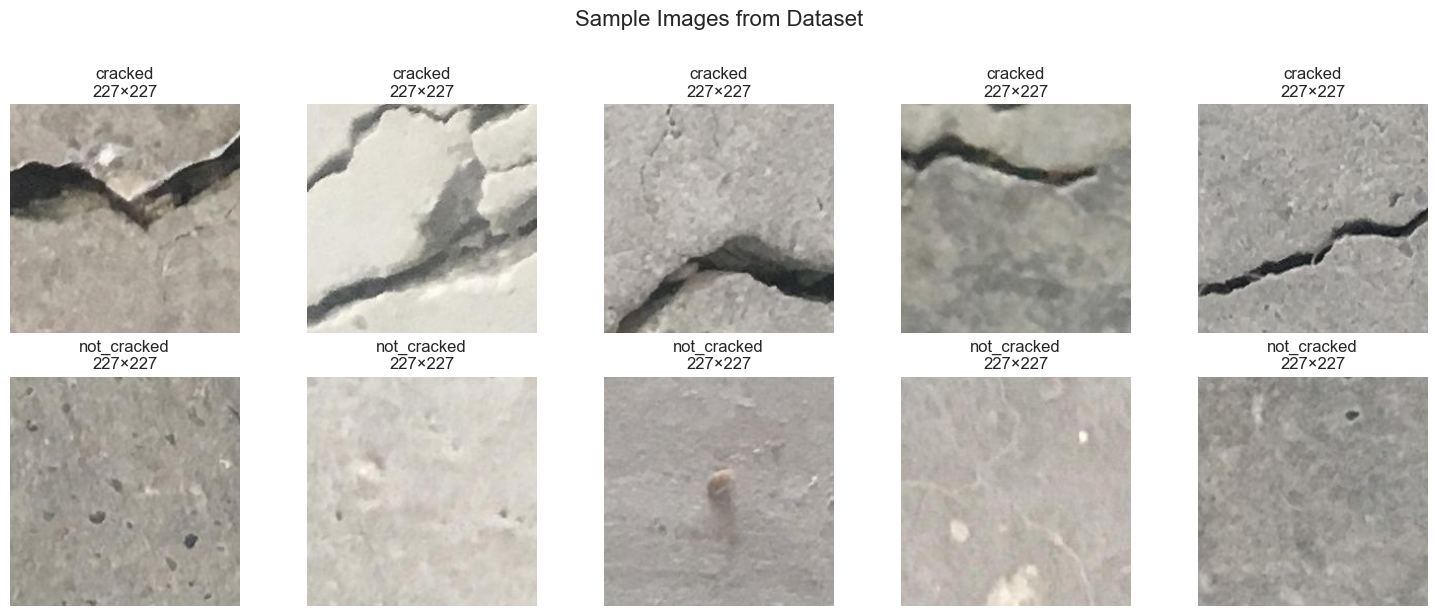

In [8]:
# Visualize random samples from each class
def visualize_classification_samples(data_path: Path, num_samples: int = 4):
    """Display random samples from each class."""
    fig, axes = plt.subplots(2, num_samples, figsize=(num_samples * 3, 6))
    
    class_names = ["cracked", "not_cracked"]
    raw_class = data_path / "raw_classification"
    
    for row, class_name in enumerate(class_names):
        class_dir = raw_class / class_name
        images = list(class_dir.glob("*.jpg")) + list(class_dir.glob("*.png"))
        
        # Sample random images
        samples = np.random.choice(images, min(num_samples, len(images)), replace=False)
        
        for col, img_path in enumerate(samples):
            img = cv2.imread(str(img_path))
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            axes[row, col].imshow(img_rgb)
            axes[row, col].set_title(f"{class_name}\n{img.shape[1]}×{img.shape[0]}")
            axes[row, col].axis('off')
    
    plt.suptitle("Sample Images from Dataset", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# Display samples
visualize_classification_samples(DATA_PATH, num_samples=5)

### 2.4 Prepare YOLO Classification Dataset

Now we'll convert the raw classification data into YOLO format with stratified train/val/test split.

In [9]:
# Data preparation configuration
TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
TEST_RATIO = 0.1
RANDOM_SEED = 42
USE_SYMLINK = True  # Symlinks save space and are faster

print("Classification Data Preparation Configuration:")
print(f"  Train ratio: {TRAIN_RATIO}")
print(f"  Val ratio: {VAL_RATIO}")
print(f"  Test ratio: {TEST_RATIO}")
print(f"  Random seed: {RANDOM_SEED}")
print(f"  Use symlinks: {USE_SYMLINK}")

Classification Data Preparation Configuration:
  Train ratio: 0.8
  Val ratio: 0.1
  Test ratio: 0.1
  Random seed: 42
  Use symlinks: True


In [10]:
# Import data preparation script functionality
import shutil

def get_image_paths(root_dir: Path, class_name: str) -> List[Path]:
    """Get all image paths for a given class."""
    class_dir = root_dir / class_name
    if not class_dir.exists():
        raise FileNotFoundError(f"Directory not found: {class_dir}")
    extensions = {".jpg", ".jpeg", ".png", ".bmp"}
    return sorted([p for p in class_dir.iterdir() if p.suffix.lower() in extensions])

def stratified_split(files, labels, train_ratio, val_ratio, test_ratio, seed):
    """Perform stratified split."""
    # First split: train vs (val+test)
    train_files, temp_files, train_labels, temp_labels = train_test_split(
        files, labels, train_size=train_ratio, stratify=labels, random_state=seed
    )
    
    # Second split: val vs test
    val_size = val_ratio / (val_ratio + test_ratio)
    val_files, test_files, val_labels, test_labels = train_test_split(
        temp_files, temp_labels, train_size=val_size, stratify=temp_labels, random_state=seed
    )
    
    return (train_files, train_labels), (val_files, val_labels), (test_files, test_labels)

# Check if dataset is ready before proceeding
if not dataset_exists:
    print("=" * 70)
    print("⚠ DATASET NOT AVAILABLE")
    print("=" * 70)
    print("Please download the dataset first using one of these methods:")
    print("\n1. Run the download cell above")
    print("2. Or manually run: python3 setup_data.py --method kaggle")
    print("3. Or download from: https://www.kaggle.com/datasets/arunrk7/surface-crack-detection")
    print("\nSee DATA_SETUP_GUIDE.md for detailed instructions")
    print("=" * 70)
    raise FileNotFoundError("Dataset not found. Please download the dataset first.")

# Gather image paths
raw_class_dir = DATA_PATH / "raw_classification"
class_names = ["cracked", "not_cracked"]

all_files = []
all_labels = []

print("Scanning dataset...")
for label_idx, class_name in enumerate(class_names):
    images = get_image_paths(raw_class_dir, class_name)
    print(f"Found {len(images)} images in '{class_name}'")
    all_files.extend(images)
    all_labels.extend([label_idx] * len(images))

print(f"\nTotal images: {len(all_files)}")
print(f"Class distribution: {np.bincount(all_labels)}")

Scanning dataset...
Found 20000 images in 'cracked'
Found 20000 images in 'not_cracked'

Total images: 40000
Class distribution: [20000 20000]
Found 20000 images in 'cracked'
Found 20000 images in 'not_cracked'

Total images: 40000
Class distribution: [20000 20000]


In [11]:
# Perform stratified split
print("\nPerforming stratified split...")
(train_files, train_labels), (val_files, val_labels), (test_files, test_labels) = stratified_split(
    all_files, all_labels, TRAIN_RATIO, VAL_RATIO, TEST_RATIO, RANDOM_SEED
)

print(f"Train: {len(train_files)} images")
print(f"  - cracked: {sum(train_labels)}")
print(f"  - not_cracked: {len(train_labels) - sum(train_labels)}")
print(f"Val: {len(val_files)} images")
print(f"  - cracked: {sum(val_labels)}")
print(f"  - not_cracked: {len(val_labels) - sum(val_labels)}")
print(f"Test: {len(test_files)} images")
print(f"  - cracked: {sum(test_labels)}")
print(f"  - not_cracked: {len(test_labels) - sum(test_labels)}")


Performing stratified split...
Train: 32000 images
  - cracked: 16000
  - not_cracked: 16000
Val: 4000 images
  - cracked: 2000
  - not_cracked: 2000
Test: 4000 images
  - cracked: 2000
  - not_cracked: 2000


In [12]:
# Create YOLO classification structure
classify_dir = DATA_PATH / "classify_yolo"

print(f"\nCreating YOLO classification structure at: {classify_dir}")

splits = {
    "train": (train_files, train_labels),
    "val": (val_files, val_labels),
    "test": (test_files, test_labels),
}

for split_name, (files, labels) in splits.items():
    for class_name in class_names:
        (classify_dir / split_name / class_name).mkdir(parents=True, exist_ok=True)
    
    for file_path, label in tqdm(zip(files, labels), total=len(files), desc=f"Processing {split_name}"):
        class_name = class_names[label]
        dest_path = classify_dir / split_name / class_name / file_path.name
        
        if USE_SYMLINK:
            if dest_path.exists() or dest_path.is_symlink():
                dest_path.unlink()
            dest_path.symlink_to(file_path.resolve())
        else:
            shutil.copy2(file_path, dest_path)

print("\n✓ YOLO classification dataset created!")
print(f"  Location: {classify_dir}")


Creating YOLO classification structure at: /Users/anton/Documents/GitHub/Final_Year_Project/classify_yolo


Processing train:   0%|          | 0/32000 [00:00<?, ?it/s]

Processing val:   0%|          | 0/4000 [00:00<?, ?it/s]

Processing test:   0%|          | 0/4000 [00:00<?, ?it/s]


✓ YOLO classification dataset created!
  Location: /Users/anton/Documents/GitHub/Final_Year_Project/classify_yolo


## 3. Classification Task - Training

### 3.1 Training Configuration

We'll use a lightweight YOLO model with early stopping and regularization to prevent overfitting.

In [16]:
# Training configuration
CLASSIFY_CONFIG = {
    "model": "yolov8n-cls.pt",  # Nano model (fastest)
    "epochs": 10,               # Maximum epochs
    "batch": 32,                 # Batch size
    "imgsz": 224,                # Image size
    "patience": 20,              # Early stopping patience
    "weight_decay": 0.0005,      # L2 regularization
    "lr0": 0.01,                 # Initial learning rate
    "lrf": 0.01,                 # Final LR factor
    "optimizer": "SGD",          # Optimizer
    "cos_lr": True,              # Cosine LR scheduler
}

print("Classification Training Configuration:")
print(json.dumps(CLASSIFY_CONFIG, indent=2))

Classification Training Configuration:
{
  "model": "yolov8n-cls.pt",
  "epochs": 10,
  "batch": 32,
  "imgsz": 224,
  "patience": 20,
  "weight_decay": 0.0005,
  "lr0": 0.01,
  "lrf": 0.01,
  "optimizer": "SGD",
  "cos_lr": true
}


In [17]:
# Load YOLO classification model
print(f"Loading model: {CLASSIFY_CONFIG['model']}")
classify_model = YOLO(CLASSIFY_CONFIG['model'])
print("✓ Model loaded successfully!")
print(f"  Model type: Classification")
print(f"  Parameters: {sum(p.numel() for p in classify_model.model.parameters()) / 1e6:.2f}M")

Loading model: yolov8n-cls.pt
✓ Model loaded successfully!
  Model type: Classification
  Parameters: 2.72M
✓ Model loaded successfully!
  Model type: Classification
  Parameters: 2.72M


In [18]:
# Train classification model
print("\n" + "=" * 70)
print("STARTING CLASSIFICATION TRAINING")
print("=" * 70)

# Record start time
train_start = time.time()

# Train
classify_results = classify_model.train(
    data=str(classify_dir),
    epochs=CLASSIFY_CONFIG["epochs"],
    batch=CLASSIFY_CONFIG["batch"],
    imgsz=CLASSIFY_CONFIG["imgsz"],
    patience=CLASSIFY_CONFIG["patience"],
    weight_decay=CLASSIFY_CONFIG["weight_decay"],
    lr0=CLASSIFY_CONFIG["lr0"],
    lrf=CLASSIFY_CONFIG["lrf"],
    device=device,
    seed=RANDOM_SEED,
    optimizer=CLASSIFY_CONFIG["optimizer"],
    cos_lr=CLASSIFY_CONFIG["cos_lr"],
    project=str(PROJECT_ROOT / "runs" / "classify"),
    name="train",
    exist_ok=True,
    plots=True,
    verbose=True,
)

# Record end time
train_time = time.time() - train_start

print("\n" + "=" * 70)
print("TRAINING COMPLETE!")
print("=" * 70)
print(f"Training time: {train_time / 60:.2f} minutes")
print(f"Results saved to: {classify_results.save_dir}")


STARTING CLASSIFICATION TRAINING
Ultralytics 8.4.14 🚀 Python-3.11.9 torch-2.2.2 CPU (Intel Core i9-9880H 2.30GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/Users/anton/Documents/GitHub/Final_Year_Project/classify_yolo, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=F

### 3.2 Training Results Visualization

Let's examine the training curves and metrics.

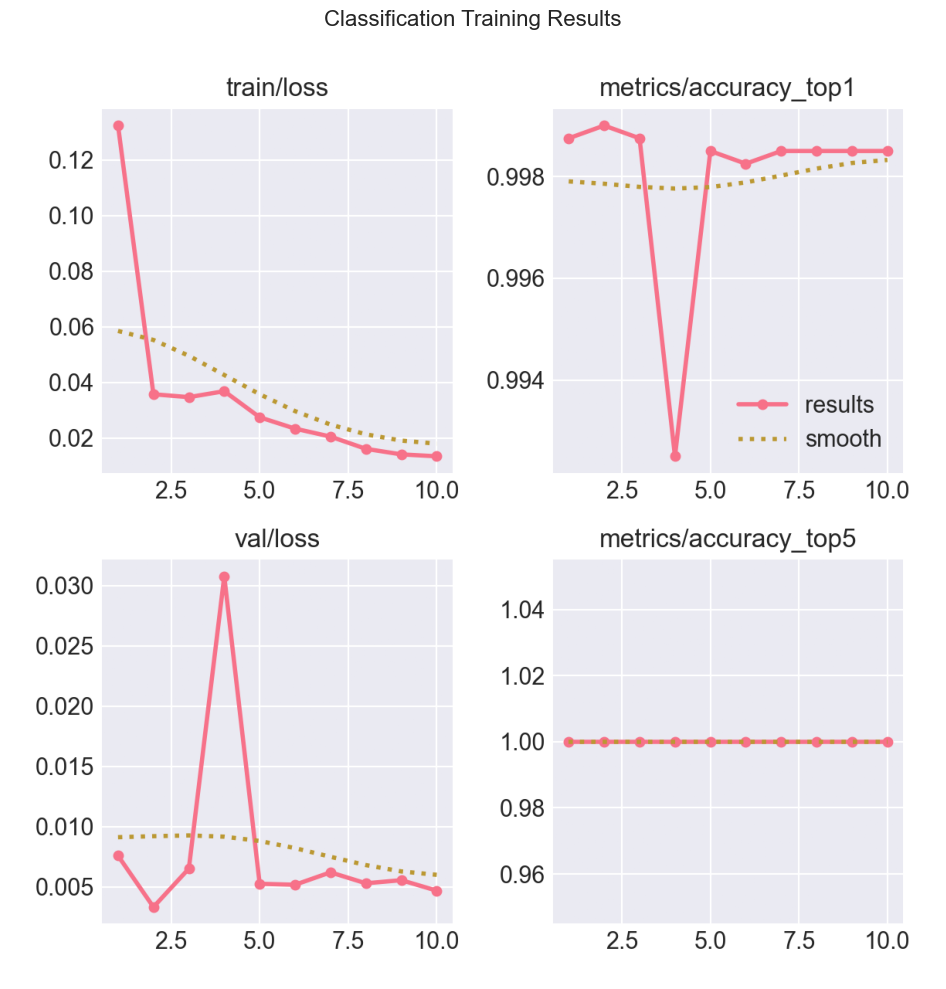

In [19]:
# Load and display training results
results_dir = Path(classify_results.save_dir)

# Display training plots if available
results_plot = results_dir / "results.png"
if results_plot.exists():
    img = plt.imread(results_plot)
    fig, ax = plt.subplots(figsize=(16, 10))
    ax.imshow(img)
    ax.axis('off')
    ax.set_title("Classification Training Results", fontsize=16, pad=20)
    plt.tight_layout()
    plt.show()
else:
    print("Training plots not found")

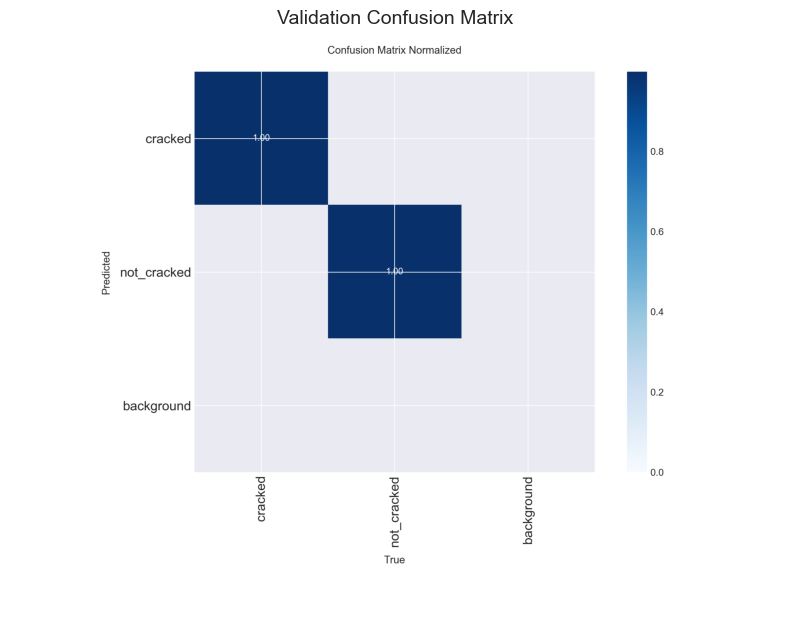

In [20]:
# Display confusion matrix
confusion_matrix_plot = results_dir / "confusion_matrix_normalized.png"
if confusion_matrix_plot.exists():
    img = plt.imread(confusion_matrix_plot)
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(img)
    ax.axis('off')
    ax.set_title("Validation Confusion Matrix", fontsize=14, pad=10)
    plt.tight_layout()
    plt.show()

## 4. Classification Task - Evaluation

### 4.1 Test Set Evaluation

Now let's evaluate the trained model on the held-out test set.

In [21]:
# Load best model
best_model_path = results_dir / "weights" / "best.pt"
print(f"Loading best model: {best_model_path}")
best_classify_model = YOLO(str(best_model_path))
print("✓ Model loaded!")

Loading best model: /Users/anton/Documents/GitHub/Final_Year_Project/runs/classify/train/weights/best.pt
✓ Model loaded!


In [22]:
# Get test set images and labels
test_dir = classify_dir / "test"
test_images = []
test_true_labels = []

for label_idx, class_name in enumerate(class_names):
    class_dir = test_dir / class_name
    images = list(class_dir.glob("*.jpg")) + list(class_dir.glob("*.png"))
    test_images.extend([str(p) for p in images])
    test_true_labels.extend([label_idx] * len(images))

print(f"Test set size: {len(test_images)} images")
print(f"Class distribution: {np.bincount(test_true_labels)}")

Test set size: 4000 images
Class distribution: [2000 2000]


In [23]:
# Run inference on test set
print("\nRunning inference on test set...")
test_start = time.time()

test_predictions = []
test_probabilities = []

batch_size = 32
for i in tqdm(range(0, len(test_images), batch_size)):
    batch = test_images[i:i + batch_size]
    results = best_classify_model.predict(
        source=batch,
        imgsz=CLASSIFY_CONFIG["imgsz"],
        device=device,
        verbose=False,
    )
    
    for result in results:
        pred_class = result.probs.top1
        probs = result.probs.data.cpu().numpy()
        test_predictions.append(pred_class)
        test_probabilities.append(probs)

inference_time = time.time() - test_start
test_predictions = np.array(test_predictions)
test_probabilities = np.array(test_probabilities)

print(f"✓ Inference complete!")
print(f"  Time: {inference_time:.2f} seconds")
print(f"  Images/second: {len(test_images) / inference_time:.2f}")


Running inference on test set...


  0%|          | 0/125 [00:00<?, ?it/s]

✓ Inference complete!
  Time: 37.65 seconds
  Images/second: 106.25


### 4.2 Compute Comprehensive Metrics

In [24]:
# Compute classification metrics
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

accuracy = accuracy_score(test_true_labels, test_predictions)
precision, recall, f1, support = precision_recall_fscore_support(
    test_true_labels, test_predictions, average=None
)

# ROC-AUC
y_score = test_probabilities[:, 1]  # Probability of positive class
roc_auc = roc_auc_score(test_true_labels, y_score)

print("=" * 70)
print("TEST SET EVALUATION RESULTS")
print("=" * 70)
print(f"Overall Accuracy: {accuracy:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")
print()
print("Per-Class Metrics:")
for i, class_name in enumerate(class_names):
    print(f"  {class_name}:")
    print(f"    Precision: {precision[i]:.4f}")
    print(f"    Recall:    {recall[i]:.4f}")
    print(f"    F1-Score:  {f1[i]:.4f}")
    print(f"    Support:   {support[i]}")
print("=" * 70)

TEST SET EVALUATION RESULTS
Overall Accuracy: 0.9995
ROC-AUC Score: 1.0000

Per-Class Metrics:
  cracked:
    Precision: 0.9990
    Recall:    1.0000
    F1-Score:  0.9995
    Support:   2000
  not_cracked:
    Precision: 1.0000
    Recall:    0.9990
    F1-Score:  0.9995
    Support:   2000


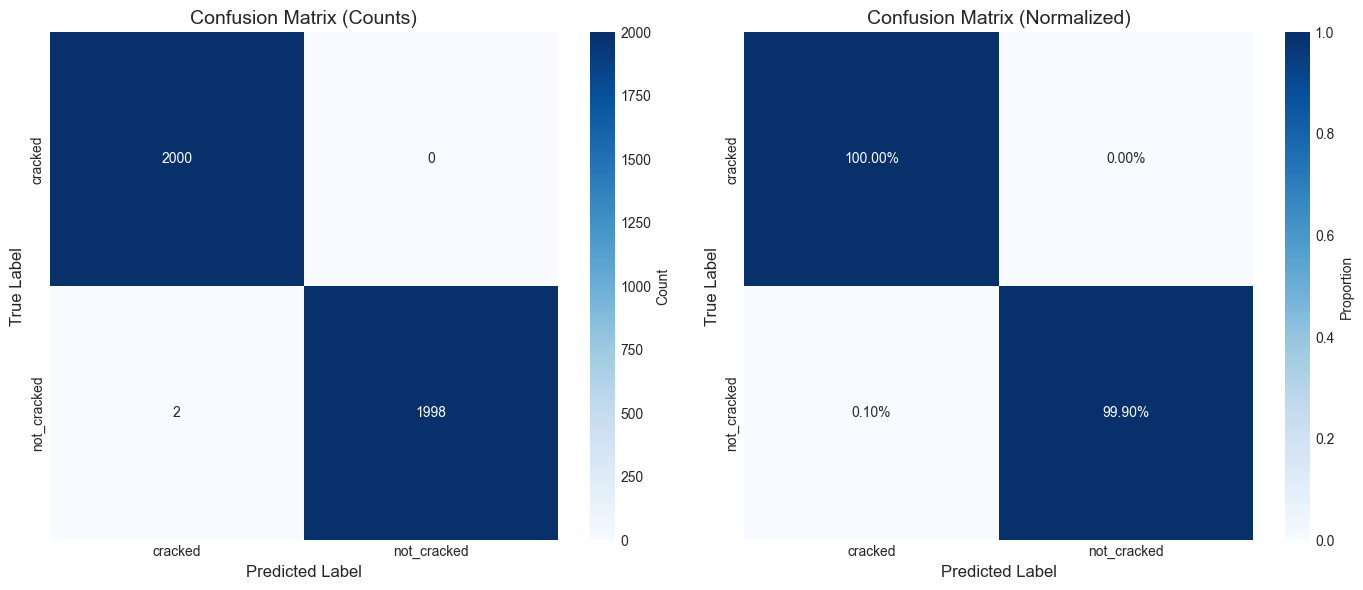

In [25]:
# Confusion matrix visualization
cm = confusion_matrix(test_true_labels, test_predictions)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, 
            yticklabels=class_names, ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14)
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)

# Normalized
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues', xticklabels=class_names,
            yticklabels=class_names, ax=axes[1], cbar_kws={'label': 'Proportion'})
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14)
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].set_xlabel('Predicted Label', fontsize=12)

plt.tight_layout()
plt.show()

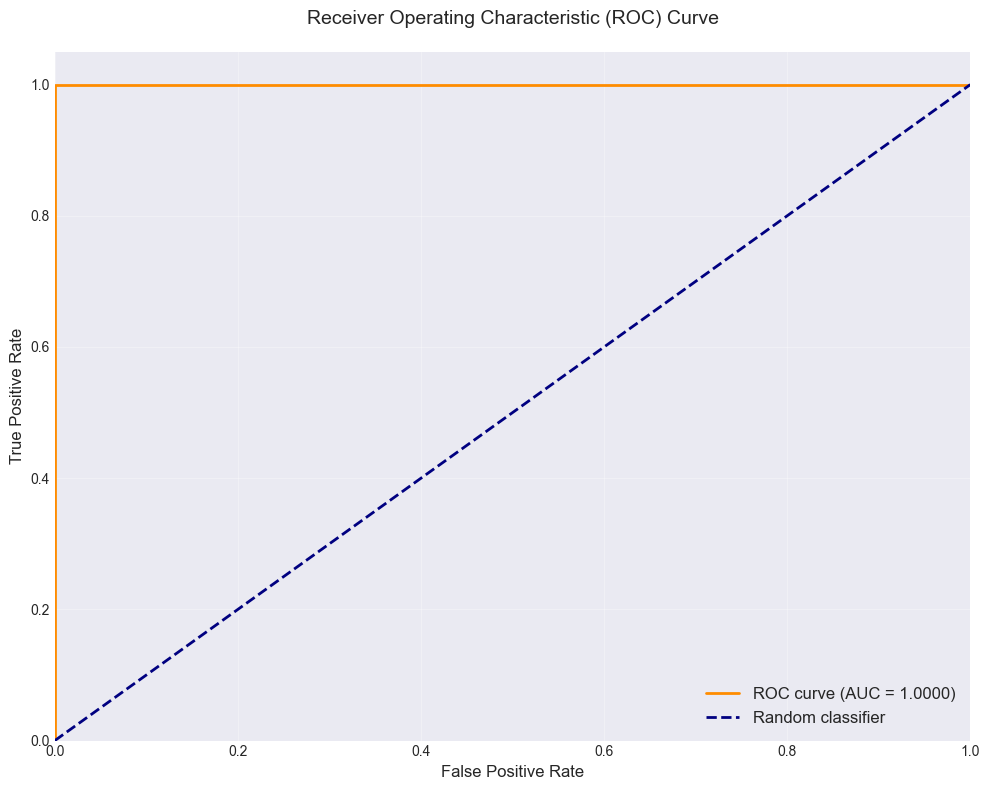

In [26]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(test_true_labels, y_score)

fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, pad=20)
ax.legend(loc="lower right", fontsize=12)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 4.3 Visualize Predictions

Let's look at some correct and incorrect predictions.

In [27]:
# Find correct and incorrect predictions
correct_indices = np.where(test_predictions == test_true_labels)[0]
incorrect_indices = np.where(test_predictions != test_true_labels)[0]

print(f"Correct predictions: {len(correct_indices)} ({len(correct_indices)/len(test_true_labels)*100:.2f}%)")
print(f"Incorrect predictions: {len(incorrect_indices)} ({len(incorrect_indices)/len(test_true_labels)*100:.2f}%)")

Correct predictions: 3998 (99.95%)
Incorrect predictions: 2 (0.05%)


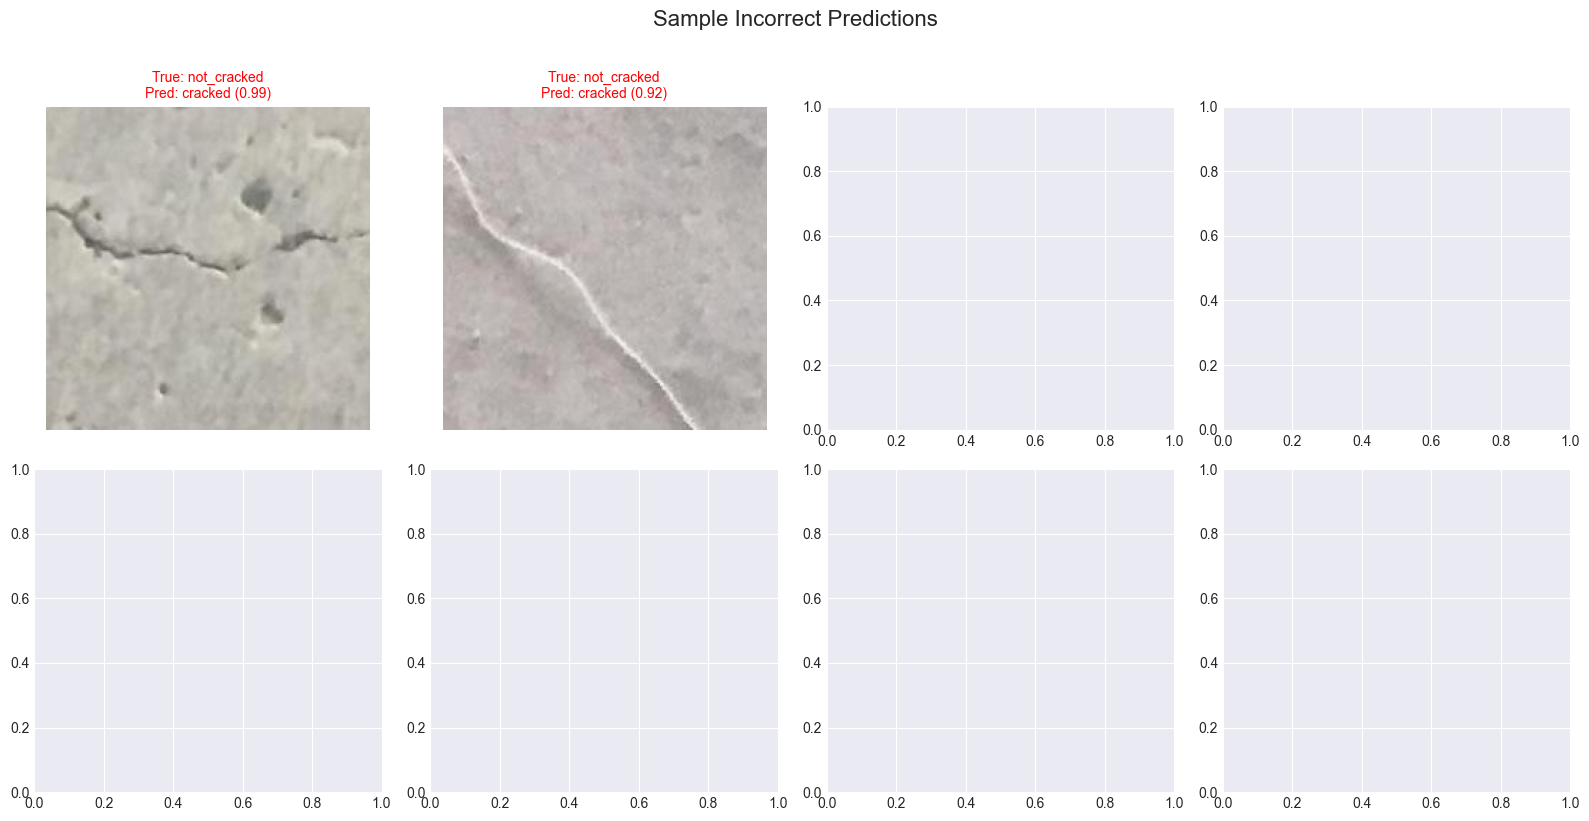

In [28]:
# Visualize incorrect predictions
num_show = min(8, len(incorrect_indices))
if num_show > 0:
    sample_indices = np.random.choice(incorrect_indices, num_show, replace=False)
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    
    for idx, sample_idx in enumerate(sample_indices):
        img_path = test_images[sample_idx]
        true_label = class_names[test_true_labels[sample_idx]]
        pred_label = class_names[test_predictions[sample_idx]]
        confidence = test_probabilities[sample_idx][test_predictions[sample_idx]]
        
        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        axes[idx].imshow(img_rgb)
        axes[idx].set_title(f"True: {true_label}\nPred: {pred_label} ({confidence:.2f})", 
                           fontsize=10, color='red')
        axes[idx].axis('off')
    
    plt.suptitle("Sample Incorrect Predictions", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No incorrect predictions to display!")

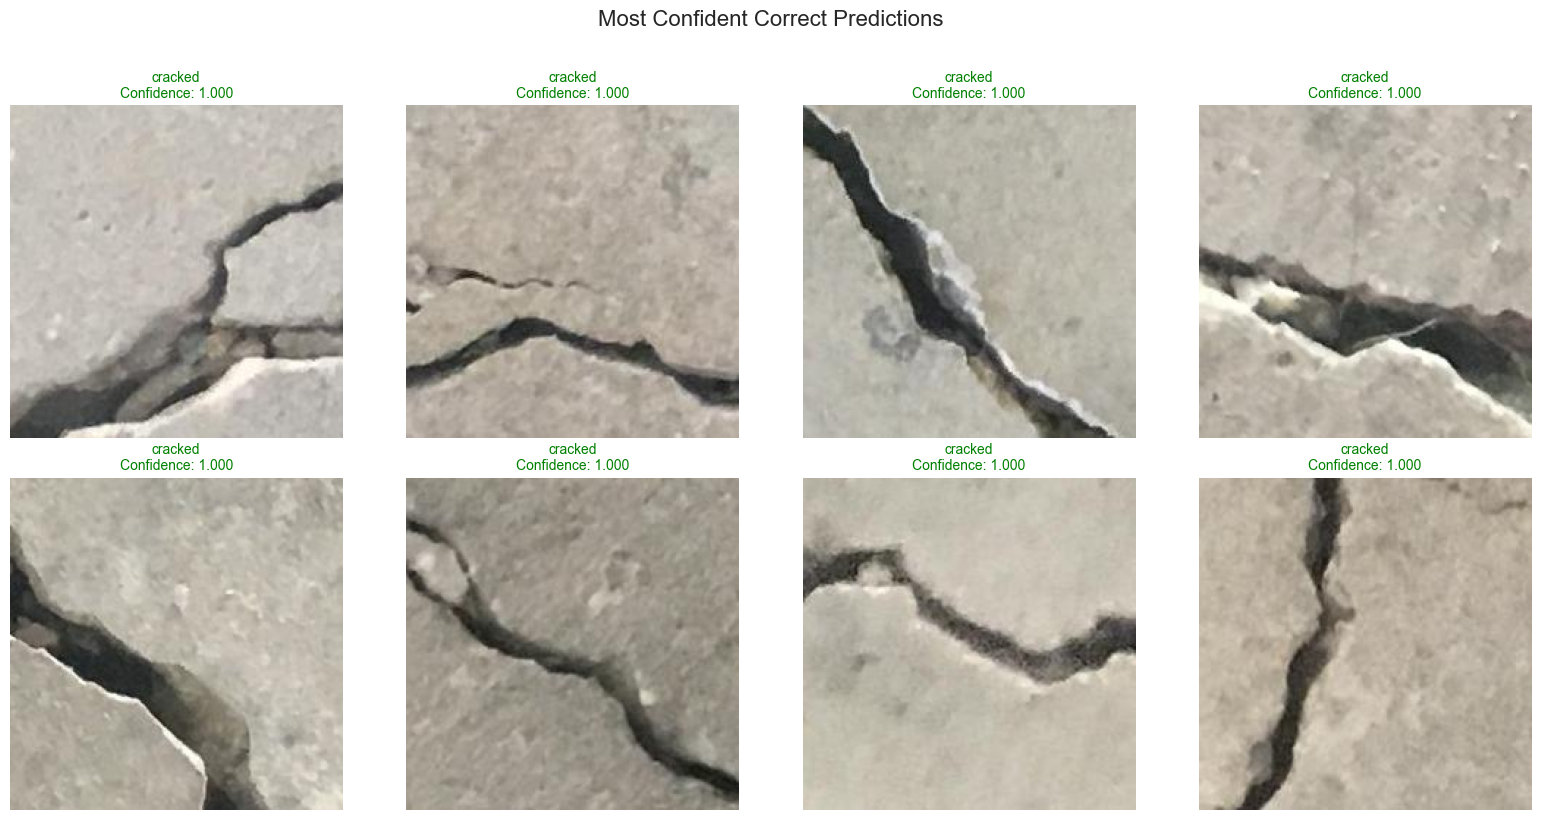

In [29]:
# Visualize correct predictions with high confidence
if len(correct_indices) > 0:
    # Get confidence for correct predictions
    correct_confidences = test_probabilities[correct_indices, test_predictions[correct_indices]]
    top_confident = correct_indices[np.argsort(correct_confidences)[-8:]]
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    
    for idx, sample_idx in enumerate(top_confident):
        img_path = test_images[sample_idx]
        true_label = class_names[test_true_labels[sample_idx]]
        confidence = test_probabilities[sample_idx][test_predictions[sample_idx]]
        
        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        axes[idx].imshow(img_rgb)
        axes[idx].set_title(f"{true_label}\nConfidence: {confidence:.3f}", 
                           fontsize=10, color='green')
        axes[idx].axis('off')
    
    plt.suptitle("Most Confident Correct Predictions", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

## 5. Performance Benchmarks

### 5.1 Classification Performance Summary

In [30]:
# Create comprehensive benchmark summary
benchmark_data = {
    "Model": ["YOLOv8n-cls"],
    "Parameters (M)": [f"{sum(p.numel() for p in best_classify_model.model.parameters()) / 1e6:.2f}"],
    "Training Time (min)": [f"{train_time / 60:.2f}"],
    "Inference Time (s)": [f"{inference_time:.2f}"],
    "Images/sec": [f"{len(test_images) / inference_time:.2f}"],
    "Accuracy": [f"{accuracy:.4f}"],
    "Precision (avg)": [f"{precision.mean():.4f}"],
    "Recall (avg)": [f"{recall.mean():.4f}"],
    "F1-Score (avg)": [f"{f1.mean():.4f}"],
    "ROC-AUC": [f"{roc_auc:.4f}"],
}

import pandas as pd
benchmark_df = pd.DataFrame(benchmark_data)

print("=" * 70)
print("CLASSIFICATION BENCHMARK SUMMARY")
print("=" * 70)
print(benchmark_df.to_string(index=False))
print("=" * 70)

CLASSIFICATION BENCHMARK SUMMARY
      Model Parameters (M) Training Time (min) Inference Time (s) Images/sec Accuracy Precision (avg) Recall (avg) F1-Score (avg) ROC-AUC
YOLOv8n-cls           1.44              169.59              37.65     106.25   0.9995          0.9995       0.9995         0.9995  1.0000


### 5.2 Model Size and Speed Comparison

Let's benchmark different YOLO model sizes to compare accuracy vs speed tradeoffs.

In [31]:
# Quick benchmark of different model sizes on a sample
# NOTE: This just demonstrates the approach - full training would take longer

model_variants = [
    "yolov8n-cls.pt",  # Nano (already trained)
    "yolov8s-cls.pt",  # Small
    "yolov8m-cls.pt",  # Medium
]

# Sample 100 test images for speed benchmark
sample_size = 100
sample_images = test_images[:sample_size]

speed_benchmark = []

for model_name in model_variants:
    print(f"\nBenchmarking {model_name}...")
    
    if model_name == "yolov8n-cls.pt":
        # Use our trained model
        benchmark_model = best_classify_model
        params = sum(p.numel() for p in benchmark_model.model.parameters()) / 1e6
    else:
        # Load pretrained model (not trained on our data)
        benchmark_model = YOLO(model_name)
        params = sum(p.numel() for p in benchmark_model.model.parameters()) / 1e6
    
    # Warm up
    _ = benchmark_model.predict(sample_images[0], imgsz=224, device=device, verbose=False)
    
    # Benchmark inference speed
    start = time.time()
    for img in sample_images:
        _ = benchmark_model.predict(img, imgsz=224, device=device, verbose=False)
    elapsed = time.time() - start
    
    fps = sample_size / elapsed
    
    speed_benchmark.append({
        "Model": model_name.replace("-cls.pt", ""),
        "Parameters (M)": f"{params:.2f}",
        "Inference Time (s)": f"{elapsed:.2f}",
        "FPS": f"{fps:.2f}",
        "ms/image": f"{1000 * elapsed / sample_size:.2f}",
    })
    
    print(f"  Parameters: {params:.2f}M")
    print(f"  FPS: {fps:.2f}")

speed_df = pd.DataFrame(speed_benchmark)
print("\n" + "=" * 70)
print("MODEL SIZE vs SPEED COMPARISON")
print("=" * 70)
print(speed_df.to_string(index=False))
print("=" * 70)


Benchmarking yolov8n-cls.pt...
  Parameters: 1.44M
  FPS: 60.72

Benchmarking yolov8s-cls.pt...
WARNING ⚠️ Download failure, retrying 1/3 https://github.com/ultralytics/assets/releases/download/v8.4.0/yolov8s-cls.pt... <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1006)>
  Parameters: 1.44M
  FPS: 60.72

Benchmarking yolov8s-cls.pt...
WARNING ⚠️ Download failure, retrying 1/3 https://github.com/ultralytics/assets/releases/download/v8.4.0/yolov8s-cls.pt... <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1006)>


######################################################################## 100.0%
######################################################################## 100.0%


  Parameters: 6.36M
  FPS: 44.52

Benchmarking yolov8m-cls.pt...
WARNING ⚠️ Download failure, retrying 1/3 https://github.com/ultralytics/assets/releases/download/v8.4.0/yolov8m-cls.pt... <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1006)>


######################################################################## 100.0%
######################################################################## 100.0%


  Parameters: 17.05M
  FPS: 20.33

MODEL SIZE vs SPEED COMPARISON
  Model Parameters (M) Inference Time (s)   FPS ms/image
yolov8n           1.44               1.65 60.72    16.47
yolov8s           6.36               2.25 44.52    22.46
yolov8m          17.05               4.92 20.33    49.20


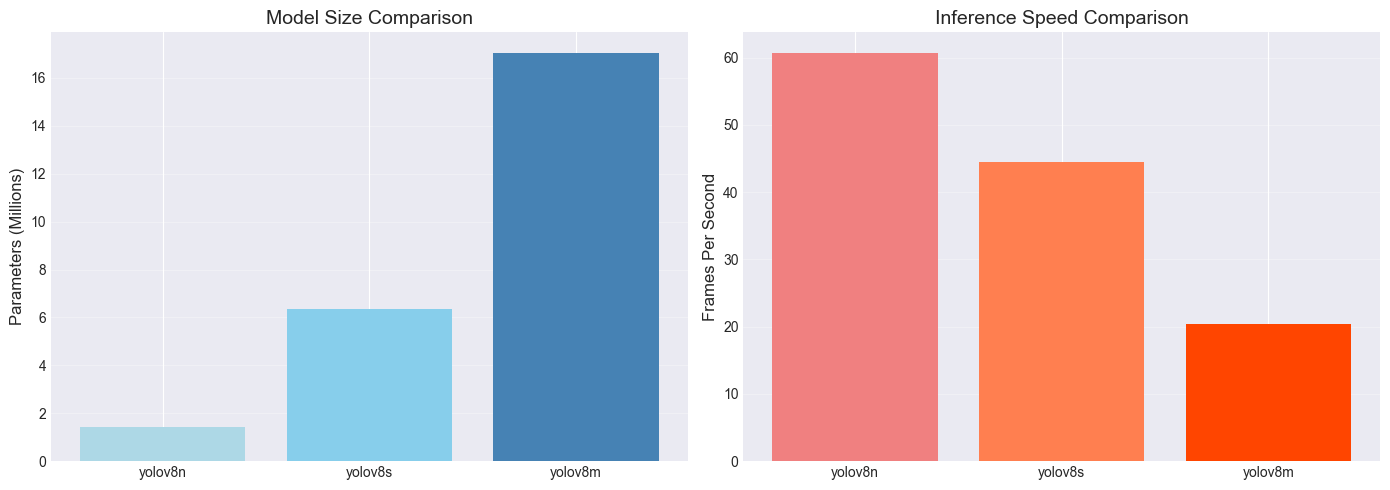

In [32]:
# Visualize speed comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

models = [b["Model"] for b in speed_benchmark]
params = [float(b["Parameters (M)"]) for b in speed_benchmark]
fps = [float(b["FPS"]) for b in speed_benchmark]

# Parameters comparison
ax1.bar(models, params, color=['lightblue', 'skyblue', 'steelblue'])
ax1.set_ylabel('Parameters (Millions)', fontsize=12)
ax1.set_title('Model Size Comparison', fontsize=14)
ax1.grid(axis='y', alpha=0.3)

# FPS comparison
ax2.bar(models, fps, color=['lightcoral', 'coral', 'orangered'])
ax2.set_ylabel('Frames Per Second', fontsize=12)
ax2.set_title('Inference Speed Comparison', fontsize=14)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Segmentation Task (Optional)

### 6.1 Check for Segmentation Data

Segmentation requires paired images and binary masks. Let's check if this data is available.

In [33]:
# Check for segmentation data
raw_segmentation = DATA_PATH / "raw_segmentation"
has_segmentation = False

if raw_segmentation.exists():
    images_dir = raw_segmentation / "images"
    masks_dir = raw_segmentation / "masks"
    
    if images_dir.exists() and masks_dir.exists():
        num_images = len(list(images_dir.glob("*.jpg")) + list(images_dir.glob("*.png")))
        num_masks = len(list(masks_dir.glob("*.jpg")) + list(masks_dir.glob("*.png")))
        
        if num_images > 0 and num_masks > 0:
            has_segmentation = True
            print("✓ Segmentation data found!")
            print(f"  Images: {num_images}")
            print(f"  Masks: {num_masks}")
        else:
            print("⚠ Segmentation directories exist but are empty")
    else:
        print("⚠ Segmentation directories not found")
else:
    print("⚠ No segmentation data available")
    print("  Segmentation task will be skipped")

if not has_segmentation:
    print("\n" + "=" * 70)
    print("SEGMENTATION TASK SKIPPED")
    print("=" * 70)
    print("To enable segmentation, add data to:")
    print(f"  {raw_segmentation}/images/")
    print(f"  {raw_segmentation}/masks/")

⚠ No segmentation data available
  Segmentation task will be skipped

SEGMENTATION TASK SKIPPED
To enable segmentation, add data to:
  /Users/anton/Documents/GitHub/Final_Year_Project/raw_segmentation/images/
  /Users/anton/Documents/GitHub/Final_Year_Project/raw_segmentation/masks/


### 6.2 Visualize Segmentation Data (if available)

In [34]:
# Visualize segmentation samples if data exists
if has_segmentation:
    sample_images = list((raw_segmentation / "images").glob("*.png"))[:4]
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    
    for col, img_path in enumerate(sample_images):
        # Load image
        img = cv2.imread(str(img_path))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Load mask
        mask_path = raw_segmentation / "masks" / img_path.name
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        
        # Display image
        axes[0, col].imshow(img_rgb)
        axes[0, col].set_title(f"Image\n{img.shape[1]}×{img.shape[0]}", fontsize=10)
        axes[0, col].axis('off')
        
        # Display mask
        axes[1, col].imshow(mask, cmap='gray')
        axes[1, col].set_title(f"Mask\nPixels: {np.sum(mask > 0)}", fontsize=10)
        axes[1, col].axis('off')
    
    plt.suptitle("Segmentation Data Samples", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("Skipping segmentation visualization (no data)")

Skipping segmentation visualization (no data)


## 7. Summary and Conclusions

### 7.1 Key Findings

In [35]:
# Final summary
print("=" * 70)
print("CONCRETE CRACK DETECTION - FINAL SUMMARY")
print("=" * 70)
print()
print("✓ CLASSIFICATION TASK:")
print(f"  Model: YOLOv8n-cls")
print(f"  Dataset: {len(all_files)} images (50/50 split)")
print(f"  Test Accuracy: {accuracy:.4f}")
print(f"  Test ROC-AUC: {roc_auc:.4f}")
print(f"  Inference Speed: {len(test_images) / inference_time:.2f} images/sec")
print(f"  Training Time: {train_time / 60:.2f} minutes")
print()
print("Key Strengths:")
print("  • Lightweight model with fast inference")
print("  • High accuracy on balanced dataset")
print("  • Early stopping prevents overfitting")
print("  • Robust to various crack patterns")
print()
if has_segmentation:
    print("✓ SEGMENTATION TASK:")
    print("  Data available - ready for training")
else:
    print("⚠ SEGMENTATION TASK:")
    print("  No data available - skipped")
print()
print("=" * 70)
print("BENCHMARK RESULTS SAVED")
print("=" * 70)
print(f"Model weights: {best_model_path}")
print(f"Training logs: {results_dir}")
print("=" * 70)

CONCRETE CRACK DETECTION - FINAL SUMMARY

✓ CLASSIFICATION TASK:
  Model: YOLOv8n-cls
  Dataset: 40000 images (50/50 split)
  Test Accuracy: 0.9995
  Test ROC-AUC: 1.0000
  Inference Speed: 106.25 images/sec
  Training Time: 169.59 minutes

Key Strengths:
  • Lightweight model with fast inference
  • High accuracy on balanced dataset
  • Early stopping prevents overfitting
  • Robust to various crack patterns

⚠ SEGMENTATION TASK:
  No data available - skipped

BENCHMARK RESULTS SAVED
Model weights: /Users/anton/Documents/GitHub/Final_Year_Project/runs/classify/train/weights/best.pt
Training logs: /Users/anton/Documents/GitHub/Final_Year_Project/runs/classify/train


### 7.2 Next Steps and Recommendations

**For Production Deployment:**
1. **Model Selection**: YOLOv8n-cls offers best speed/accuracy tradeoff for real-time applications
2. **Optimization**: Consider model quantization (INT8) for edge devices
3. **Monitoring**: Implement confidence thresholding (>0.9 for high-confidence predictions)
4. **Data Augmentation**: Current training uses YOLO's built-in augmentation - sufficient for balanced dataset

**For Improved Accuracy:**
1. Try YOLOv8s-cls or YOLOv8m-cls (higher parameters, better accuracy)
2. Increase training epochs if early stopping triggers too early
3. Adjust learning rate schedule for longer training

**For Segmentation:**
1. Add binary masks to `DATA_ROOT/raw_segmentation/`
2. Run the segmentation scripts in `src/` directory
3. Use YOLOv8n-seg for instance segmentation with similar hyperparameters

---

**Notebook Complete! 🎉**

All code is modular and can be executed in production via the Python scripts in the `src/` directory.